# 05 — Round of 32 Prediction

This notebook builds a simulated Round of 32 from the predicted group-stage standings and applies the trained models to predict knockout match outcomes.

## Project Setup

The group-stage outputs, feature base data, and trained models are loaded.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

PROJECT_DIR = Path("..").resolve()
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
OUTPUT_DIR = PROJECT_DIR / "output"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = OUTPUT_DIR / "models"
PREDICTIONS_DIR = OUTPUT_DIR / "predictions"

for directory in [TABLES_DIR, FIGURES_DIR, PREDICTIONS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project folder:", PROJECT_DIR)
print("Processed data folder:", PROCESSED_DIR)
print("Predictions folder:", PREDICTIONS_DIR)


Project folder: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026
Processed data folder: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\data\processed
Predictions folder: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\predictions


## Load Previous Results

The predicted group standings and trained models from previous steps are imported.

In [2]:
standings = pd.read_csv(PREDICTIONS_DIR / "worldcup2026_predicted_group_standings.csv")
top2 = pd.read_csv(PREDICTIONS_DIR / "worldcup2026_predicted_top2_qualified.csv")
third_place = pd.read_csv(PREDICTIONS_DIR / "worldcup2026_predicted_third_place_ranking.csv")
group_predictions = pd.read_csv(PREDICTIONS_DIR / "worldcup2026_group_match_predictions.csv")

base_matches = pd.read_csv(PROCESSED_DIR / "base_matches_2026_teams_from_1995.csv")
base_matches["date"] = pd.to_datetime(base_matches["date"], errors="coerce")

result_model = joblib.load(MODELS_DIR / "best_match_result_model.joblib")
goals_a_model = joblib.load(MODELS_DIR / "best_team_a_goals_model.joblib")
goals_b_model = joblib.load(MODELS_DIR / "best_team_b_goals_model.joblib")

print("Predicted standings:", standings.shape)
print("Top 2 qualified:", top2.shape)
print("Third-place ranking:", third_place.shape)
print("Base historical matches:", base_matches.shape)

display(standings.head())
display(top2.head())
display(third_place.head())


Predicted standings: (48, 11)
Top 2 qualified: (24, 11)
Third-place ranking: (12, 12)
Base historical matches: (12900, 12)


,group,team,played,wins,draws,losses,goals_for,goals_against,goal_difference,points,group_rank
0,Group A,Mexico,3,3,0,0,6,1,5,9,1
1,Group A,South Africa,3,1,1,1,4,4,0,4,2
2,Group A,Korea Republic,3,1,0,2,6,4,2,3,3
3,Group A,Czechia/Denmark/North Macedonia/Republic of Ir...,3,0,1,2,1,8,-7,1,4
4,Group B,Switzerland,3,2,1,0,8,2,6,7,1


,group,team,played,wins,draws,losses,goals_for,goals_against,goal_difference,points,group_rank
0,Group A,Mexico,3,3,0,0,6,1,5,9,1
1,Group A,South Africa,3,1,1,1,4,4,0,4,2
2,Group B,Switzerland,3,2,1,0,8,2,6,7,1
3,Group B,Canada,3,2,0,1,8,2,6,6,2
4,Group C,Brazil,3,2,0,1,6,3,3,6,1


,group,team,played,wins,draws,losses,goals_for,goals_against,goal_difference,points,group_rank,third_place_rank
0,Group C,Scotland,3,1,1,1,4,4,0,4,3,1
1,Group K,Uzbekistan,3,1,1,1,4,4,0,4,3,2
2,Group D,Australia,3,1,0,2,7,4,3,3,3,3
3,Group I,Senegal,3,1,0,2,7,4,3,3,3,4
4,Group A,Korea Republic,3,1,0,2,6,4,2,3,3,5


## Build the 32 Qualified Teams

The top two teams from each group and the eight best third-place teams are selected.

In [3]:
best_third_place = third_place.sort_values(
    ["points", "goal_difference", "goals_for"],
    ascending=[False, False, False]
).head(8).copy()

qualified_teams = pd.concat([
    top2.assign(qualification_type="top2"),
    best_third_place.assign(qualification_type="best_third")
], ignore_index=True)

qualified_teams = qualified_teams.sort_values(
    ["group", "group_rank", "qualification_type"]
).reset_index(drop=True)

print("Qualified teams:", qualified_teams.shape)
print("Unique qualified teams:", qualified_teams["team"].nunique())

display(qualified_teams[[
    "group", "group_rank", "team", "points", "goal_difference",
    "goals_for", "qualification_type"
]])

qualified_teams.to_csv(PREDICTIONS_DIR / "worldcup2026_predicted_round_of_32_qualified.csv", index=False)
qualified_teams.to_csv(TABLES_DIR / "worldcup2026_predicted_round_of_32_qualified.csv", index=False)

print("Saved:", PREDICTIONS_DIR / "worldcup2026_predicted_round_of_32_qualified.csv")


Qualified teams: (32, 13)
Unique qualified teams: 32


,group,group_rank,team,points,goal_difference,goals_for,qualification_type
0,Group A,1,Mexico,9,5,6,top2
1,Group A,2,South Africa,4,0,4,top2
2,Group A,3,Korea Republic,3,2,6,best_third
3,Group B,1,Switzerland,7,6,8,top2
4,Group B,2,Canada,6,6,8,top2
5,Group C,1,Brazil,6,3,6,top2
6,Group C,2,Morocco,4,1,4,top2
7,Group C,3,Scotland,4,0,4,best_third
8,Group D,1,USA,7,2,5,top2
9,Group D,2,Paraguay,4,0,4,top2


Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\predictions\worldcup2026_predicted_round_of_32_qualified.csv


## Qualification Visualization

The predicted qualified teams are shown by points and qualification type.

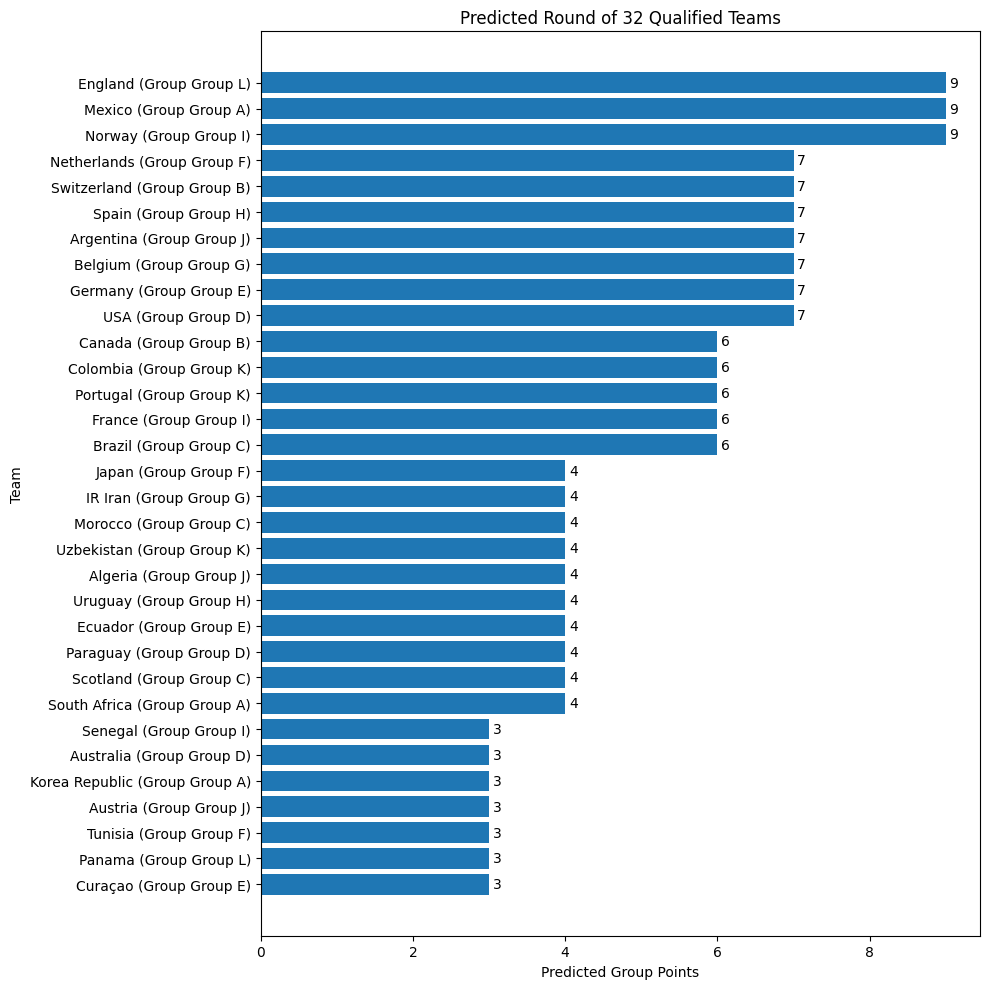

In [4]:
plot_qualified = qualified_teams.sort_values(
    ["points", "goal_difference", "goals_for"],
    ascending=True
).copy()

plot_qualified["label"] = (
    plot_qualified["team"] + " (Group " + plot_qualified["group"].astype(str) + ")"
)

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(plot_qualified["label"], plot_qualified["points"])
ax.set_title("Predicted Round of 32 Qualified Teams")
ax.set_xlabel("Predicted Group Points")
ax.set_ylabel("Team")

for i, value in enumerate(plot_qualified["points"]):
    ax.text(value + 0.05, i, str(value), va="center")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "wc2026_round_of_32_qualified_points.png", dpi=150)
plt.show()


## Create a Simulated Round of 32 Bracket

A simplified bracket is created from group winners, runners-up, and best third-place teams.

In [5]:
group_winners = standings[standings["group_rank"] == 1].sort_values("group").copy()
group_runners_up = standings[standings["group_rank"] == 2].sort_values("group").copy()
best_thirds = best_third_place.sort_values("third_place_rank").copy()

winners = group_winners["team"].tolist()
runners = group_runners_up["team"].tolist()
thirds = best_thirds["team"].tolist()

round32_pairs = []

for i in range(8):
    round32_pairs.append({
        "round32_match": i + 1,
        "team_a": winners[i],
        "team_b": thirds[::-1][i],
        "bracket_source": "group_winner_vs_best_third"
    })

for i in range(4):
    round32_pairs.append({
        "round32_match": 9 + i,
        "team_a": winners[8 + i],
        "team_b": runners[i],
        "bracket_source": "group_winner_vs_runner_up"
    })

for i in range(4):
    round32_pairs.append({
        "round32_match": 13 + i,
        "team_a": runners[4 + 2*i],
        "team_b": runners[4 + 2*i + 1],
        "bracket_source": "runner_up_vs_runner_up"
    })

round32_fixtures = pd.DataFrame(round32_pairs)
round32_fixtures["date"] = pd.Timestamp("2026-06-28")
round32_fixtures["stage"] = "Round of 32"
round32_fixtures["neutral"] = True
round32_fixtures["tournament"] = "FIFA World Cup 2026"

display(round32_fixtures)

round32_fixtures.to_csv(PREDICTIONS_DIR / "worldcup2026_round_of_32_fixtures_simulated.csv", index=False)
round32_fixtures.to_csv(TABLES_DIR / "worldcup2026_round_of_32_fixtures_simulated.csv", index=False)

print("Saved:", PREDICTIONS_DIR / "worldcup2026_round_of_32_fixtures_simulated.csv")


,round32_match,team_a,team_b,bracket_source,date,stage,neutral,tournament
0,1,Mexico,Curaçao,group_winner_vs_best_third,2026-06-28,Round of 32,True,FIFA World Cup 2026
1,2,Switzerland,Tunisia,group_winner_vs_best_third,2026-06-28,Round of 32,True,FIFA World Cup 2026
2,3,Brazil,Austria,group_winner_vs_best_third,2026-06-28,Round of 32,True,FIFA World Cup 2026
3,4,USA,Korea Republic,group_winner_vs_best_third,2026-06-28,Round of 32,True,FIFA World Cup 2026
4,5,Germany,Senegal,group_winner_vs_best_third,2026-06-28,Round of 32,True,FIFA World Cup 2026
5,6,Netherlands,Australia,group_winner_vs_best_third,2026-06-28,Round of 32,True,FIFA World Cup 2026
6,7,Belgium,Uzbekistan,group_winner_vs_best_third,2026-06-28,Round of 32,True,FIFA World Cup 2026
7,8,Spain,Scotland,group_winner_vs_best_third,2026-06-28,Round of 32,True,FIFA World Cup 2026
8,9,Norway,South Africa,group_winner_vs_runner_up,2026-06-28,Round of 32,True,FIFA World Cup 2026
9,10,Argentina,Canada,group_winner_vs_runner_up,2026-06-28,Round of 32,True,FIFA World Cup 2026


Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\predictions\worldcup2026_round_of_32_fixtures_simulated.csv


## Historical Feature Functions

The same feature logic from feature engineering is reused for knockout prediction.

In [6]:
def get_team_history(df, team, match_date):
    history = df[
        ((df["home_team_clean"] == team) | (df["away_team_clean"] == team)) &
        (df["date"] < match_date)
    ].sort_values("date")

    return history


def get_recent_team_stats(df, team, match_date, n_matches=10):
    history = get_team_history(df, team, match_date).tail(n_matches)

    if history.empty:
        return {
            "matches": 0,
            "win_rate": 0.0,
            "draw_rate": 0.0,
            "loss_rate": 0.0,
            "avg_goals_scored": 0.0,
            "avg_goals_conceded": 0.0,
            "avg_goal_diff": 0.0,
            "points_per_match": 0.0,
        }

    wins = 0
    draws = 0
    losses = 0
    goals_scored = []
    goals_conceded = []
    goal_diffs = []
    points = []

    for _, row in history.iterrows():
        if row["home_team_clean"] == team:
            scored = row["home_score"]
            conceded = row["away_score"]
        else:
            scored = row["away_score"]
            conceded = row["home_score"]

        if pd.isna(scored) or pd.isna(conceded):
            continue

        goals_scored.append(scored)
        goals_conceded.append(conceded)
        goal_diffs.append(scored - conceded)

        if scored > conceded:
            wins += 1
            points.append(3)
        elif scored < conceded:
            losses += 1
            points.append(0)
        else:
            draws += 1
            points.append(1)

    valid_matches = len(points)

    if valid_matches == 0:
        return {
            "matches": 0,
            "win_rate": 0.0,
            "draw_rate": 0.0,
            "loss_rate": 0.0,
            "avg_goals_scored": 0.0,
            "avg_goals_conceded": 0.0,
            "avg_goal_diff": 0.0,
            "points_per_match": 0.0,
        }

    return {
        "matches": valid_matches,
        "win_rate": wins / valid_matches,
        "draw_rate": draws / valid_matches,
        "loss_rate": losses / valid_matches,
        "avg_goals_scored": np.mean(goals_scored),
        "avg_goals_conceded": np.mean(goals_conceded),
        "avg_goal_diff": np.mean(goal_diffs),
        "points_per_match": np.mean(points),
    }


def get_pair_h2h_stats(df, team_a, team_b, match_date):
    h2h = df[
        (
            (df["home_team_clean"] == team_a) &
            (df["away_team_clean"] == team_b)
        ) |
        (
            (df["home_team_clean"] == team_b) &
            (df["away_team_clean"] == team_a)
        )
    ]

    h2h = h2h[h2h["date"] < match_date].sort_values("date")

    if h2h.empty:
        return {
            "h2h_matches": 0,
            "team_a_h2h_win_rate": 0.0,
            "team_b_h2h_win_rate": 0.0,
            "h2h_draw_rate": 0.0,
            "team_a_h2h_avg_goals": 0.0,
            "team_b_h2h_avg_goals": 0.0,
        }

    team_a_wins = 0
    team_b_wins = 0
    draws = 0
    goals_a = []
    goals_b = []

    for _, row in h2h.iterrows():
        if row["home_team_clean"] == team_a:
            a_score = row["home_score"]
            b_score = row["away_score"]
        else:
            a_score = row["away_score"]
            b_score = row["home_score"]

        if pd.isna(a_score) or pd.isna(b_score):
            continue

        goals_a.append(a_score)
        goals_b.append(b_score)

        if a_score > b_score:
            team_a_wins += 1
        elif a_score < b_score:
            team_b_wins += 1
        else:
            draws += 1

    valid_matches = len(goals_a)

    if valid_matches == 0:
        return {
            "h2h_matches": 0,
            "team_a_h2h_win_rate": 0.0,
            "team_b_h2h_win_rate": 0.0,
            "h2h_draw_rate": 0.0,
            "team_a_h2h_avg_goals": 0.0,
            "team_b_h2h_avg_goals": 0.0,
        }

    return {
        "h2h_matches": valid_matches,
        "team_a_h2h_win_rate": team_a_wins / valid_matches,
        "team_b_h2h_win_rate": team_b_wins / valid_matches,
        "h2h_draw_rate": draws / valid_matches,
        "team_a_h2h_avg_goals": np.mean(goals_a),
        "team_b_h2h_avg_goals": np.mean(goals_b),
    }


def create_match_features(df, team_a, team_b, match_date, neutral=True, tournament=None):
    a_last5 = get_recent_team_stats(df, team_a, match_date, n_matches=5)
    b_last5 = get_recent_team_stats(df, team_b, match_date, n_matches=5)

    a_last10 = get_recent_team_stats(df, team_a, match_date, n_matches=10)
    b_last10 = get_recent_team_stats(df, team_b, match_date, n_matches=10)

    h2h = get_pair_h2h_stats(df, team_a, team_b, match_date)

    features = {
        "team_a": team_a,
        "team_b": team_b,
        "date": match_date,
        "tournament": tournament,
        "neutral": neutral,
        "team_a_matches_last5": a_last5["matches"],
        "team_b_matches_last5": b_last5["matches"],
        "team_a_win_rate_last5": a_last5["win_rate"],
        "team_b_win_rate_last5": b_last5["win_rate"],
        "team_a_draw_rate_last5": a_last5["draw_rate"],
        "team_b_draw_rate_last5": b_last5["draw_rate"],
        "team_a_loss_rate_last5": a_last5["loss_rate"],
        "team_b_loss_rate_last5": b_last5["loss_rate"],
        "team_a_points_per_match_last5": a_last5["points_per_match"],
        "team_b_points_per_match_last5": b_last5["points_per_match"],
        "team_a_matches_last10": a_last10["matches"],
        "team_b_matches_last10": b_last10["matches"],
        "team_a_win_rate_last10": a_last10["win_rate"],
        "team_b_win_rate_last10": b_last10["win_rate"],
        "team_a_draw_rate_last10": a_last10["draw_rate"],
        "team_b_draw_rate_last10": b_last10["draw_rate"],
        "team_a_loss_rate_last10": a_last10["loss_rate"],
        "team_b_loss_rate_last10": b_last10["loss_rate"],
        "team_a_avg_goals_scored_last10": a_last10["avg_goals_scored"],
        "team_b_avg_goals_scored_last10": b_last10["avg_goals_scored"],
        "team_a_avg_goals_conceded_last10": a_last10["avg_goals_conceded"],
        "team_b_avg_goals_conceded_last10": b_last10["avg_goals_conceded"],
        "team_a_avg_goal_diff_last10": a_last10["avg_goal_diff"],
        "team_b_avg_goal_diff_last10": b_last10["avg_goal_diff"],
        "team_a_points_per_match_last10": a_last10["points_per_match"],
        "team_b_points_per_match_last10": b_last10["points_per_match"],
        "win_rate_diff_last10": a_last10["win_rate"] - b_last10["win_rate"],
        "points_per_match_diff_last10": a_last10["points_per_match"] - b_last10["points_per_match"],
        "avg_goals_scored_diff_last10": a_last10["avg_goals_scored"] - b_last10["avg_goals_scored"],
        "avg_goals_conceded_diff_last10": a_last10["avg_goals_conceded"] - b_last10["avg_goals_conceded"],
        "avg_goal_diff_diff_last10": a_last10["avg_goal_diff"] - b_last10["avg_goal_diff"],
        **h2h,
    }

    return features


## Build Round of 32 Features

The simulated bracket is transformed into the model input format.

In [7]:
feature_rows = []

for _, row in round32_fixtures.iterrows():
    features = create_match_features(
        base_matches,
        team_a=row["team_a"],
        team_b=row["team_b"],
        match_date=row["date"],
        neutral=True,
        tournament="FIFA World Cup 2026",
    )

    features["round32_match"] = row["round32_match"]
    features["stage"] = row["stage"]
    features["bracket_source"] = row["bracket_source"]

    feature_rows.append(features)

round32_features = pd.DataFrame(feature_rows)

display(round32_features.head())
print("Round of 32 feature dataset:", round32_features.shape)


,team_a,team_b,date,tournament,neutral,team_a_matches_last5,team_b_matches_last5,team_a_win_rate_last5,team_b_win_rate_last5,team_a_draw_rate_last5,...,avg_goal_diff_diff_last10,h2h_matches,team_a_h2h_win_rate,team_b_h2h_win_rate,h2h_draw_rate,team_a_h2h_avg_goals,team_b_h2h_avg_goals,round32_match,stage,bracket_source
0,Mexico,Curaçao,2026-06-28,FIFA World Cup 2026,True,5,5,0.6,0.2,0.4,...,0.7,1,1.0,0.0,0.0,2.0,0.0,1,Round of 32,group_winner_vs_best_third
1,Switzerland,Tunisia,2026-06-28,FIFA World Cup 2026,True,5,5,0.2,0.2,0.6,...,1.4,2,0.5,0.0,0.5,1.5,1.0,2,Round of 32,group_winner_vs_best_third
2,Brazil,Austria,2026-06-28,FIFA World Cup 2026,True,5,5,0.6,0.8,0.2,...,-0.9,2,1.0,0.0,0.0,2.5,0.5,3,Round of 32,group_winner_vs_best_third
3,USA,Korea Republic,2026-06-28,FIFA World Cup 2026,True,5,5,0.4,0.6,0.0,...,-0.2,5,0.4,0.4,0.2,1.0,1.0,4,Round of 32,group_winner_vs_best_third
4,Germany,Senegal,2026-06-28,FIFA World Cup 2026,True,5,5,1.0,0.6,0.0,...,0.9,0,0.0,0.0,0.0,0.0,0.0,5,Round of 32,group_winner_vs_best_third


Round of 32 feature dataset: (16, 45)


## Predict Round of 32 Matches

The trained models predict result probabilities and expected goals for every knockout match.

In [8]:
non_model_columns = [
    "team_a", "team_b", "date",
    "team_a_goals", "team_b_goals", "result",
    "round32_match", "stage", "bracket_source"
]

X_round32 = round32_features[
    [col for col in round32_features.columns if col not in non_model_columns]
].copy()

round32_predictions = round32_features[[
    "round32_match", "date", "stage", "bracket_source", "team_a", "team_b"
]].copy()

round32_predictions["predicted_result"] = result_model.predict(X_round32)

if hasattr(result_model, "predict_proba"):
    probability_df = pd.DataFrame(
        result_model.predict_proba(X_round32),
        columns=[f"prob_{label}" for label in result_model.classes_]
    )
    round32_predictions = pd.concat(
        [round32_predictions.reset_index(drop=True), probability_df.reset_index(drop=True)],
        axis=1
    )

round32_predictions["predicted_team_a_goals"] = goals_a_model.predict(X_round32).clip(min=0)
round32_predictions["predicted_team_b_goals"] = goals_b_model.predict(X_round32).clip(min=0)

round32_predictions["predicted_team_a_goals_rounded"] = (
    round32_predictions["predicted_team_a_goals"].round().astype(int)
)
round32_predictions["predicted_team_b_goals_rounded"] = (
    round32_predictions["predicted_team_b_goals"].round().astype(int)
)

round32_predictions["predicted_score"] = (
    round32_predictions["predicted_team_a_goals_rounded"].astype(str)
    + " - "
    + round32_predictions["predicted_team_b_goals_rounded"].astype(str)
)

display(round32_predictions)


,round32_match,date,stage,bracket_source,team_a,team_b,predicted_result,prob_draw,prob_team_a_win,prob_team_b_win,predicted_team_a_goals,predicted_team_b_goals,predicted_team_a_goals_rounded,predicted_team_b_goals_rounded,predicted_score
0,1,2026-06-28,Round of 32,group_winner_vs_best_third,Mexico,Curaçao,team_a_win,0.270572,0.726655,0.002773,2.315253,0.350162,2,0,2 - 0
1,2,2026-06-28,Round of 32,group_winner_vs_best_third,Switzerland,Tunisia,team_a_win,0.394973,0.600761,0.004266,2.213888,0.587961,2,1,2 - 1
2,3,2026-06-28,Round of 32,group_winner_vs_best_third,Brazil,Austria,team_a_win,0.451533,0.542273,0.006194,1.854284,0.840543,2,1,2 - 1
3,4,2026-06-28,Round of 32,group_winner_vs_best_third,USA,Korea Republic,team_a_win,0.412961,0.578300,0.008739,1.944721,0.908943,2,1,2 - 1
4,5,2026-06-28,Round of 32,group_winner_vs_best_third,Germany,Senegal,team_a_win,0.382944,0.610809,0.006247,2.155063,0.743331,2,1,2 - 1
5,6,2026-06-28,Round of 32,group_winner_vs_best_third,Netherlands,Australia,team_a_win,0.425143,0.570171,0.004686,2.064984,0.591500,2,1,2 - 1
6,7,2026-06-28,Round of 32,group_winner_vs_best_third,Belgium,Uzbekistan,team_a_win,0.350861,0.646331,0.002809,2.559956,0.438130,3,0,3 - 0
7,8,2026-06-28,Round of 32,group_winner_vs_best_third,Spain,Scotland,team_a_win,0.403621,0.592727,0.003651,2.141088,0.522027,2,1,2 - 1
8,9,2026-06-28,Round of 32,group_winner_vs_runner_up,Norway,South Africa,team_a_win,0.368153,0.629124,0.002723,2.361348,0.470562,2,0,2 - 0
9,10,2026-06-28,Round of 32,group_winner_vs_runner_up,Argentina,Canada,team_a_win,0.246792,0.751711,0.001497,2.388825,0.211367,2,0,2 - 0


## Decide Knockout Winners

Knockout matches cannot end in a draw, so tied rounded scores are resolved using model probabilities and expected goals.

In [9]:
def choose_knockout_winner(row):
    goals_a = row["predicted_team_a_goals_rounded"]
    goals_b = row["predicted_team_b_goals_rounded"]

    if goals_a > goals_b:
        return row["team_a"]
    if goals_b > goals_a:
        return row["team_b"]

    prob_a = row.get("prob_team_a_win", np.nan)
    prob_b = row.get("prob_team_b_win", np.nan)

    if not pd.isna(prob_a) and not pd.isna(prob_b):
        if prob_a >= prob_b:
            return row["team_a"]
        return row["team_b"]

    expected_goal_diff = row["predicted_team_a_goals"] - row["predicted_team_b_goals"]
    if expected_goal_diff >= 0:
        return row["team_a"]
    return row["team_b"]


round32_predictions["predicted_winner"] = round32_predictions.apply(choose_knockout_winner, axis=1)
round32_predictions["predicted_loser"] = np.where(
    round32_predictions["predicted_winner"] == round32_predictions["team_a"],
    round32_predictions["team_b"],
    round32_predictions["team_a"]
)

display(round32_predictions[[
    "round32_match", "team_a", "team_b", "predicted_score",
    "predicted_result", "predicted_winner"
]])


,round32_match,team_a,team_b,predicted_score,predicted_result,predicted_winner
0,1,Mexico,Curaçao,2 - 0,team_a_win,Mexico
1,2,Switzerland,Tunisia,2 - 1,team_a_win,Switzerland
2,3,Brazil,Austria,2 - 1,team_a_win,Brazil
3,4,USA,Korea Republic,2 - 1,team_a_win,USA
4,5,Germany,Senegal,2 - 1,team_a_win,Germany
5,6,Netherlands,Australia,2 - 1,team_a_win,Netherlands
6,7,Belgium,Uzbekistan,3 - 0,team_a_win,Belgium
7,8,Spain,Scotland,2 - 1,team_a_win,Spain
8,9,Norway,South Africa,2 - 0,team_a_win,Norway
9,10,Argentina,Canada,2 - 0,team_a_win,Argentina


## Export Round of 32 Predictions

The full Round of 32 prediction table is saved.

In [10]:
round32_predictions.to_csv(PREDICTIONS_DIR / "worldcup2026_round_of_32_predictions.csv", index=False)
round32_predictions.to_csv(TABLES_DIR / "worldcup2026_round_of_32_predictions.csv", index=False)

round32_winners = round32_predictions[[
    "round32_match", "predicted_winner", "predicted_loser"
]].copy()

round32_winners.to_csv(PREDICTIONS_DIR / "worldcup2026_round_of_32_winners.csv", index=False)
round32_winners.to_csv(TABLES_DIR / "worldcup2026_round_of_32_winners.csv", index=False)

print("Saved:", PREDICTIONS_DIR / "worldcup2026_round_of_32_predictions.csv")
print("Saved:", PREDICTIONS_DIR / "worldcup2026_round_of_32_winners.csv")


Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\predictions\worldcup2026_round_of_32_predictions.csv
Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\predictions\worldcup2026_round_of_32_winners.csv


## Round of 32 Visualizations

The predicted knockout matches are summarized with presentation-ready charts.

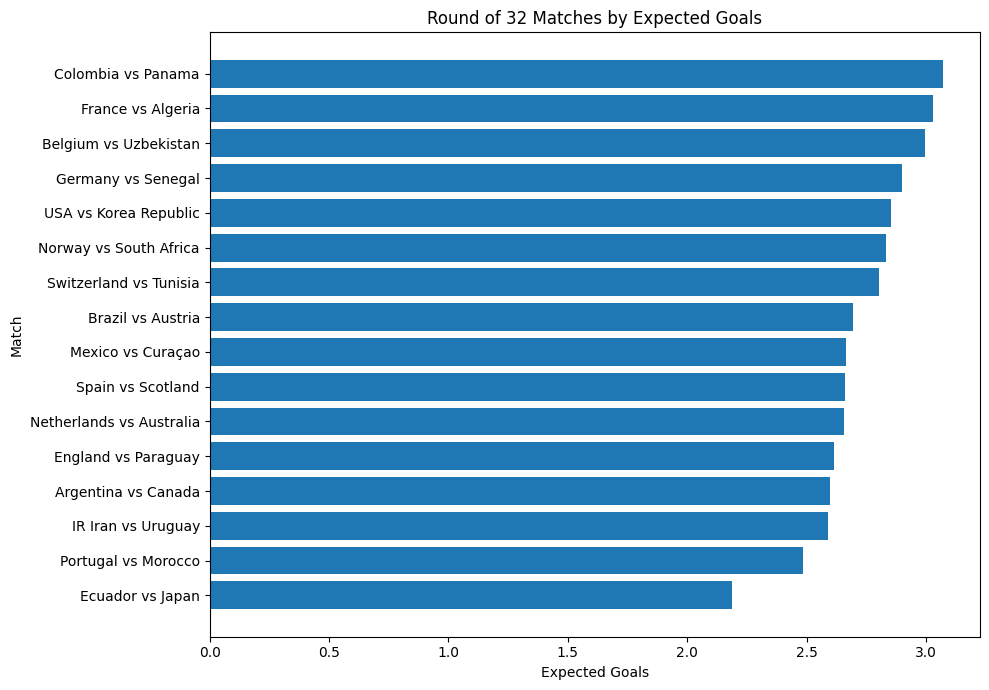

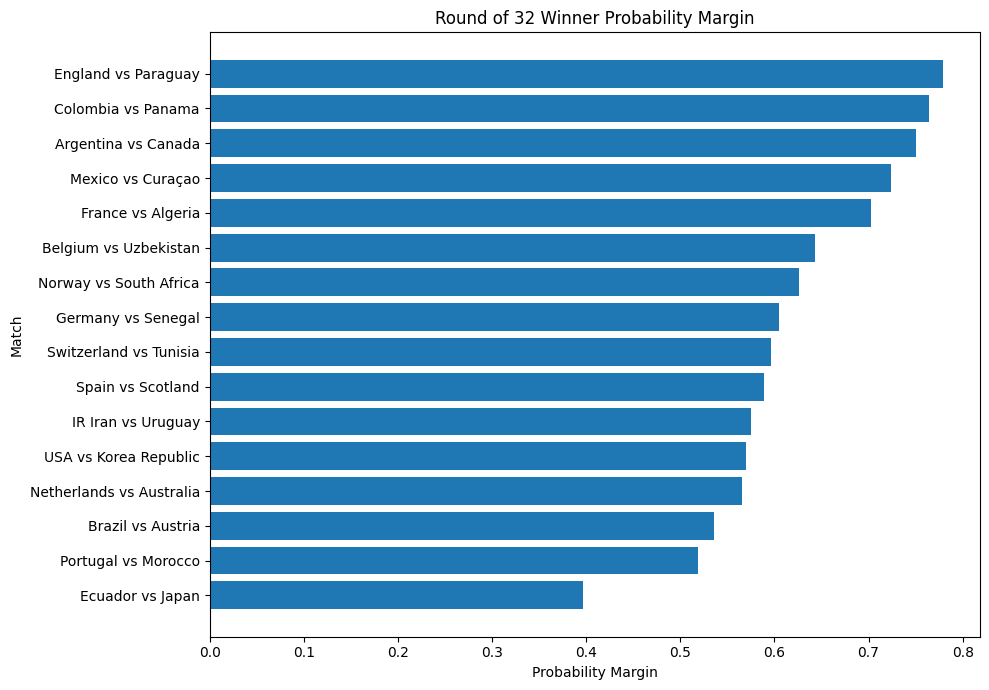

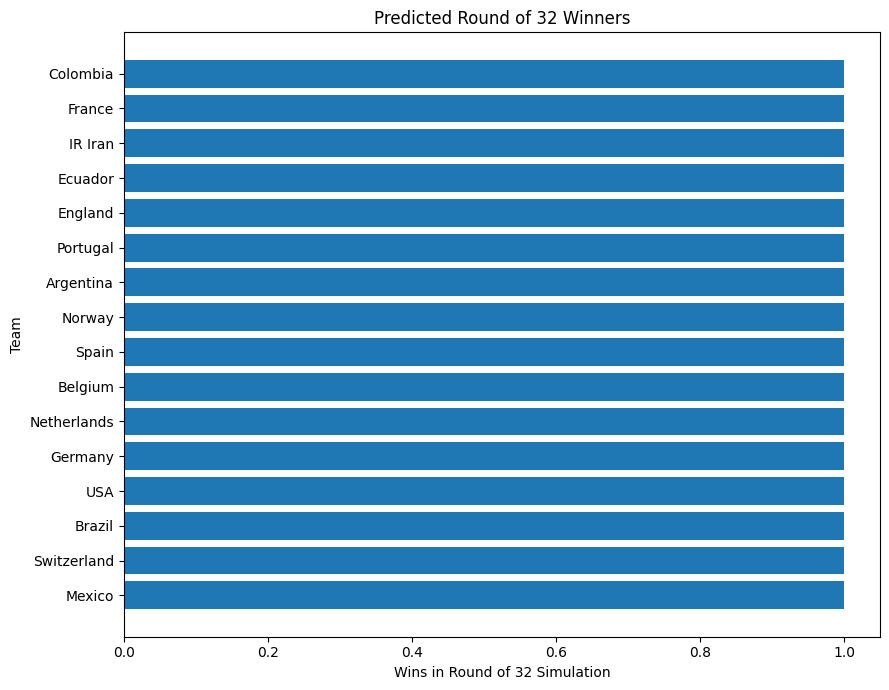

In [11]:
plot_df = round32_predictions.copy()
plot_df["match"] = plot_df["team_a"] + " vs " + plot_df["team_b"]
plot_df["total_expected_goals"] = (
    plot_df["predicted_team_a_goals"] + plot_df["predicted_team_b_goals"]
)
plot_df = plot_df.sort_values("total_expected_goals", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_df["match"], plot_df["total_expected_goals"])
ax.set_title("Round of 32 Matches by Expected Goals")
ax.set_xlabel("Expected Goals")
ax.set_ylabel("Match")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "wc2026_round_of_32_expected_goals.png", dpi=150)
plt.show()

prob_cols = [col for col in round32_predictions.columns if col.startswith("prob_")]
if "prob_team_a_win" in prob_cols and "prob_team_b_win" in prob_cols:
    margin_df = round32_predictions.copy()
    margin_df["winner_probability_margin"] = (
        margin_df[["prob_team_a_win", "prob_team_b_win"]].max(axis=1)
        - margin_df[["prob_team_a_win", "prob_team_b_win"]].min(axis=1)
    )
    margin_df["match"] = margin_df["team_a"] + " vs " + margin_df["team_b"]
    margin_df = margin_df.sort_values("winner_probability_margin", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(margin_df["match"], margin_df["winner_probability_margin"])
    ax.set_title("Round of 32 Winner Probability Margin")
    ax.set_xlabel("Probability Margin")
    ax.set_ylabel("Match")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "wc2026_round_of_32_probability_margin.png", dpi=150)
    plt.show()

winner_counts = round32_predictions["predicted_winner"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(winner_counts.index, winner_counts.values)
ax.set_title("Predicted Round of 32 Winners")
ax.set_xlabel("Wins in Round of 32 Simulation")
ax.set_ylabel("Team")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "wc2026_round_of_32_predicted_winners.png", dpi=150)
plt.show()


## Final Output Overview

The Round of 32 fixture simulation, predictions, winners, and plots are saved for the next knockout stage.

In [12]:
print("Prediction files:")
print(" - output/predictions/worldcup2026_predicted_round_of_32_qualified.csv")
print(" - output/predictions/worldcup2026_round_of_32_fixtures_simulated.csv")
print(" - output/predictions/worldcup2026_round_of_32_predictions.csv")
print(" - output/predictions/worldcup2026_round_of_32_winners.csv")

print("\nTable files:")
print(" - output/tables/worldcup2026_predicted_round_of_32_qualified.csv")
print(" - output/tables/worldcup2026_round_of_32_fixtures_simulated.csv")
print(" - output/tables/worldcup2026_round_of_32_predictions.csv")
print(" - output/tables/worldcup2026_round_of_32_winners.csv")

print("\nFigure files:")
print(" - output/figures/wc2026_round_of_32_qualified_points.png")
print(" - output/figures/wc2026_round_of_32_expected_goals.png")
print(" - output/figures/wc2026_round_of_32_probability_margin.png")
print(" - output/figures/wc2026_round_of_32_predicted_winners.png")

print("\nRound of 32 prediction completed.")


Prediction files:
 - output/predictions/worldcup2026_predicted_round_of_32_qualified.csv
 - output/predictions/worldcup2026_round_of_32_fixtures_simulated.csv
 - output/predictions/worldcup2026_round_of_32_predictions.csv
 - output/predictions/worldcup2026_round_of_32_winners.csv

Table files:
 - output/tables/worldcup2026_predicted_round_of_32_qualified.csv
 - output/tables/worldcup2026_round_of_32_fixtures_simulated.csv
 - output/tables/worldcup2026_round_of_32_predictions.csv
 - output/tables/worldcup2026_round_of_32_winners.csv

Figure files:
 - output/figures/wc2026_round_of_32_qualified_points.png
 - output/figures/wc2026_round_of_32_expected_goals.png
 - output/figures/wc2026_round_of_32_probability_margin.png
 - output/figures/wc2026_round_of_32_predicted_winners.png

Round of 32 prediction completed.
